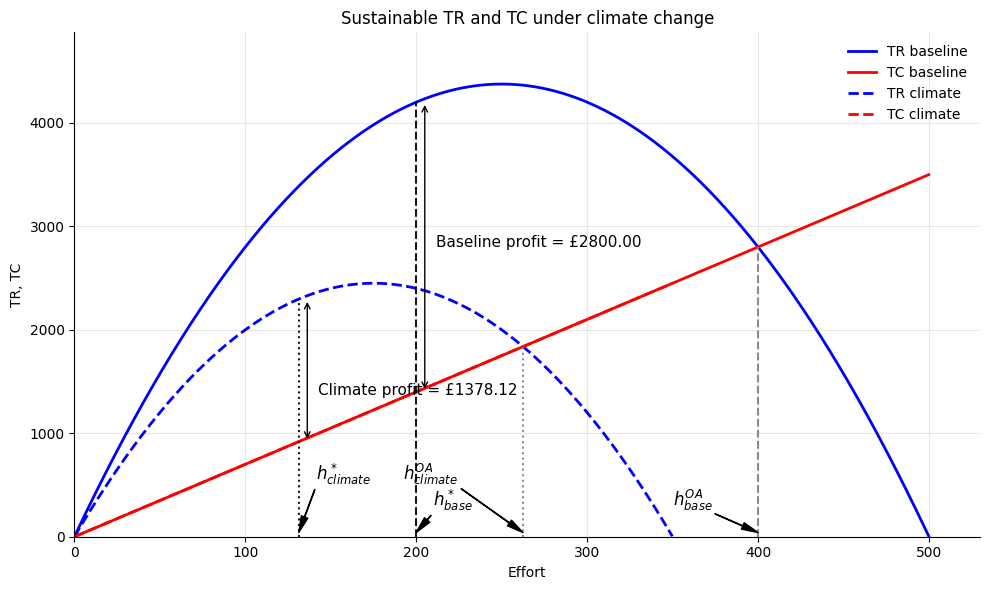

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from scipy.optimize import fmin

# ----------------------------
# Common parameters
# ----------------------------
theta = 0.001
p = 10
c = 7
lw = 2

# ----------------------------
# Scenarios
# ----------------------------
# Baseline
gamma_base = 0.5
Kmax_base = 3500

# Climate change scenario
# Example: lower reproduction and lower carrying capacity
gamma_cc = 0.35
Kmax_cc = 2800

def solve_fishery(gamma, Kmax, theta, p, c):
    # Stocks
    x = np.arange(1, Kmax + 1).reshape((Kmax, 1))

    # Biological growth
    dxdt = gamma * x * (1 - x / Kmax)

    # Sustainable effort
    effort_ss = (gamma * x * (1 - x / Kmax)) / (theta * x)

    # Revenue, cost, profit
    TR_ss = dxdt * p
    TC = effort_ss * c
    profits = TR_ss - TC

    # Open access equilibrium
    soa = c / (p * theta)
    eoa = gamma * soa * (1 - (soa / Kmax)) / (theta * soa)
    revs_oa = p * theta * soa * eoa
    cost_oa = c * eoa
    profits_oa = revs_oa - cost_oa

    # Profit-maximising equilibrium
    negative_profits = lambda xval: -1 * (
        (p * theta * xval - c) * (gamma * xval * (1 - (xval / Kmax))) / (theta * xval)
    )

    x_initial_guess = min(3000, Kmax - 1)
    x_star = fmin(negative_profits, x_initial_guess, disp=False)

    h_star = gamma * x_star * (1 - (x_star / Kmax)) / (theta * x_star)
    revs_star = p * theta * x_star * h_star
    cost_star = c * h_star
    profits_star = revs_star - cost_star

    # Flatten for plotting
    effort_ss = effort_ss.flatten()
    TR_ss = TR_ss.flatten()
    TC = TC.flatten()
    profits = profits.flatten()

    # Sort by effort so lines plot properly
    order = np.argsort(effort_ss)
    effort_ss = effort_ss[order]
    TR_ss = TR_ss[order]
    TC = TC[order]
    profits = profits[order]

    return {
        "gamma": gamma,
        "Kmax": Kmax,
        "x": x,
        "dxdt": dxdt,
        "effort_ss": effort_ss,
        "TR_ss": TR_ss,
        "TC": TC,
        "profits": profits,
        "soa": soa,
        "eoa": eoa,
        "revs_oa": revs_oa,
        "cost_oa": cost_oa,
        "profits_oa": profits_oa,
        "x_star": x_star[0],
        "h_star": h_star[0],
        "revs_star": revs_star[0],
        "cost_star": cost_star[0],
        "profits_star": profits_star[0]
    }

# Solve both scenarios
base = solve_fishery(gamma_base, Kmax_base, theta, p, c)
cc = solve_fishery(gamma_cc, Kmax_cc, theta, p, c)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline
ax.plot(base["effort_ss"], base["TR_ss"], c="b", lw=lw, label="TR baseline")
ax.plot(base["effort_ss"], base["TC"], c="r", lw=lw, label="TC baseline")

# Climate change
ax.plot(cc["effort_ss"], cc["TR_ss"], c="b", lw=lw, ls="--", label="TR climate")
ax.plot(cc["effort_ss"], cc["TC"], c="r", lw=lw, ls="--", label="TC climate")

# Baseline equilibrium markers
ax.plot((base["h_star"], base["h_star"]), (0, base["revs_star"]), 'k--', alpha=0.9)
ax.plot((base["eoa"], base["eoa"]), (0, c * base["eoa"]), 'grey', ls='--', alpha=0.9)

ax.annotate(
    '', xy=(base["h_star"] + 5, base["revs_star"]),
    xytext=(base["h_star"] + 5, base["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Baseline profit = £{base["profits_star"]:.2f}',
    xy=(base["h_star"] + 5, (base["revs_star"] + base["cost_star"]) / 2),
    xytext=(8, 0),
    textcoords='offset points',
    fontsize=11
)

ax.annotate(
    r'$h^*_{base}$',
    xy=(base["h_star"], 40),
    xytext=(base["h_star"] + 10, 300),
    arrowprops=dict(facecolor='black', width=.3, headwidth=5),
    fontsize=12
)

ax.annotate(
    r'$h^{OA}_{base}$',
    xy=(base["eoa"], 40),
    xytext=(base["eoa"] - 50, 300),
    arrowprops=dict(facecolor='black', width=.3, headwidth=5),
    fontsize=12
)

# Climate equilibrium markers
ax.plot((cc["h_star"], cc["h_star"]), (0, cc["revs_star"]), 'k:', alpha=0.9)
ax.plot((cc["eoa"], cc["eoa"]), (0, c * cc["eoa"]), color='grey', ls=':', alpha=0.9)

ax.annotate(
    '', xy=(cc["h_star"] + 5, cc["revs_star"]),
    xytext=(cc["h_star"] + 5, cc["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Climate profit = £{cc["profits_star"]:.2f}',
    xy=(cc["h_star"] + 5, (cc["revs_star"] + cc["cost_star"]) / 2),
    xytext=(8, -18),
    textcoords='offset points',
    fontsize=11
)

ax.annotate(
    r'$h^*_{climate}$',
    xy=(cc["h_star"], 40),
    xytext=(cc["h_star"] + 10, 550),
    arrowprops=dict(facecolor='black', width=.3, headwidth=5),
    fontsize=12
)

ax.annotate(
    r'$h^{OA}_{climate}$',
    xy=(cc["eoa"], 40),
    xytext=(cc["eoa"] - 70, 550),
    arrowprops=dict(facecolor='black', width=.3, headwidth=5),
    fontsize=12
)

ax.set_xlabel("Effort")
ax.set_ylabel("TR, TC")
ax.set_title("Sustainable TR and TC under climate change")
ax.set_xlim(0, max(base["effort_ss"].max(), cc["effort_ss"].max()) + 30)
ax.set_ylim(0, max(base["TR_ss"].max(), cc["TR_ss"].max()) + 500)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

sbn.despine()
plt.tight_layout()
plt.show()

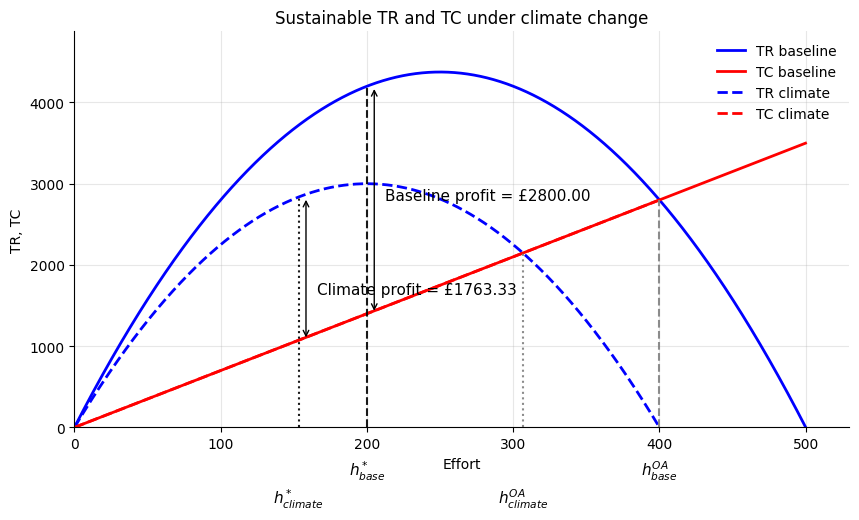

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from scipy.optimize import fmin

# ----------------------------
# Common parameters
# ----------------------------
theta = 0.001
p = 10
c = 7
lw = 2

# ----------------------------
# Scenarios
# ----------------------------
# Baseline
gamma_base = 0.5
Kmax_base = 3500

# Climate change scenario
# Example: lower reproduction and lower carrying capacity
gamma_cc = 0.4
Kmax_cc = 3000

def solve_fishery(gamma, Kmax, theta, p, c):
    # Stocks
    x = np.arange(1, Kmax + 1).reshape((Kmax, 1))

    # Biological growth
    dxdt = gamma * x * (1 - x / Kmax)

    # Sustainable effort
    effort_ss = (gamma * x * (1 - x / Kmax)) / (theta * x)

    # Revenue, cost, profit
    TR_ss = dxdt * p
    TC = effort_ss * c
    profits = TR_ss - TC

    # Open access equilibrium
    soa = c / (p * theta)
    eoa = gamma * soa * (1 - (soa / Kmax)) / (theta * soa)
    revs_oa = p * theta * soa * eoa
    cost_oa = c * eoa
    profits_oa = revs_oa - cost_oa

    # Profit-maximising equilibrium
    negative_profits = lambda xval: -1 * (
        (p * theta * xval - c) * (gamma * xval * (1 - (xval / Kmax))) / (theta * xval)
    )

    x_initial_guess = min(3000, Kmax - 1)
    x_star = fmin(negative_profits, x_initial_guess, disp=False)

    h_star = gamma * x_star * (1 - (x_star / Kmax)) / (theta * x_star)
    revs_star = p * theta * x_star * h_star
    cost_star = c * h_star
    profits_star = revs_star - cost_star

    # Flatten for plotting
    effort_ss = effort_ss.flatten()
    TR_ss = TR_ss.flatten()
    TC = TC.flatten()
    profits = profits.flatten()

    # Sort by effort so lines plot properly
    order = np.argsort(effort_ss)
    effort_ss = effort_ss[order]
    TR_ss = TR_ss[order]
    TC = TC[order]
    profits = profits[order]

    return {
        "gamma": gamma,
        "Kmax": Kmax,
        "x": x,
        "dxdt": dxdt,
        "effort_ss": effort_ss,
        "TR_ss": TR_ss,
        "TC": TC,
        "profits": profits,
        "soa": soa,
        "eoa": eoa,
        "revs_oa": revs_oa,
        "cost_oa": cost_oa,
        "profits_oa": profits_oa,
        "x_star": x_star[0],
        "h_star": h_star[0],
        "revs_star": revs_star[0],
        "cost_star": cost_star[0],
        "profits_star": profits_star[0]
    }

# Solve both scenarios
base = solve_fishery(gamma_base, Kmax_base, theta, p, c)
cc = solve_fishery(gamma_cc, Kmax_cc, theta, p, c)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline
ax.plot(base["effort_ss"], base["TR_ss"], c="b", lw=lw, label="TR baseline")
ax.plot(base["effort_ss"], base["TC"], c="r", lw=lw, label="TC baseline")

# Climate change
ax.plot(cc["effort_ss"], cc["TR_ss"], c="b", lw=lw, ls="--", label="TR climate")
ax.plot(cc["effort_ss"], cc["TC"], c="r", lw=lw, ls="--", label="TC climate")

# Baseline equilibrium markers
ax.plot((base["h_star"], base["h_star"]), (0, base["revs_star"]), 'k--', alpha=0.9)
ax.plot((base["eoa"], base["eoa"]), (0, c * base["eoa"]), 'grey', ls='--', alpha=0.9)

ax.annotate(
    '', xy=(base["h_star"] + 5, base["revs_star"]),
    xytext=(base["h_star"] + 5, base["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Baseline profit = £{base["profits_star"]:.2f}',
    xy=(base["h_star"] + 5, (base["revs_star"] + base["cost_star"]) / 2),
    xytext=(8, 0),
    textcoords='offset points',
    fontsize=11
)

# Climate equilibrium markers
ax.plot((cc["h_star"], cc["h_star"]), (0, cc["revs_star"]), 'k:', alpha=0.9)
ax.plot((cc["eoa"], cc["eoa"]), (0, c * cc["eoa"]), color='grey', ls=':', alpha=0.9)

ax.annotate(
    '', xy=(cc["h_star"] + 5, cc["revs_star"]),
    xytext=(cc["h_star"] + 5, cc["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Climate profit = £{cc["profits_star"]:.2f}',
    xy=(cc["h_star"] + 5, (cc["revs_star"] + cc["cost_star"]) / 2),
    xytext=(8, -18),
    textcoords='offset points',
    fontsize=11
)

# Labels on the x-axis instead of arrow annotations
xaxis_transform = ax.get_xaxis_transform()

ax.text(
    base["h_star"], -0.08, r'$h^*_{base}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    base["eoa"], -0.08, r'$h^{OA}_{base}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    cc["h_star"], -0.15, r'$h^*_{climate}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    cc["eoa"], -0.15, r'$h^{OA}_{climate}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.set_xlabel("Effort")
ax.set_ylabel("TR, TC")
ax.set_title("Sustainable TR and TC under climate change")
ax.set_xlim(0, max(base["effort_ss"].max(), cc["effort_ss"].max()) + 30)
ax.set_ylim(0, max(base["TR_ss"].max(), cc["TR_ss"].max()) + 500)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

sbn.despine()
plt.subplots_adjust(bottom=0.22)
plt.show()

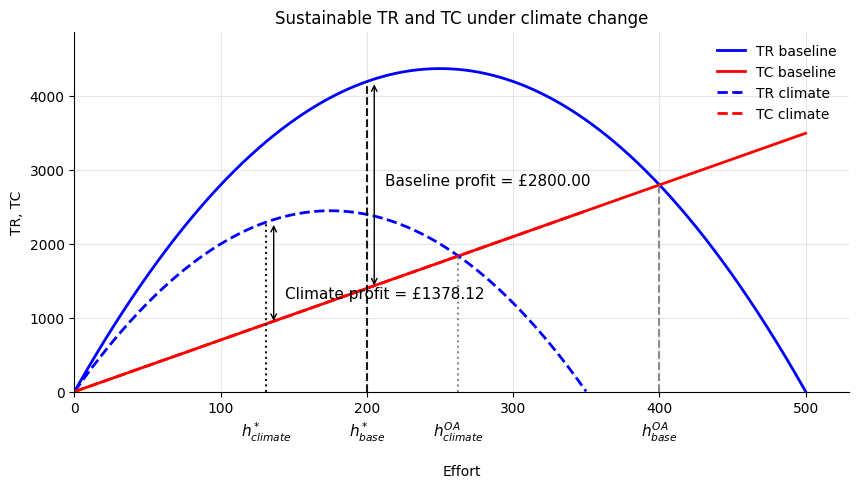

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from scipy.optimize import fmin

# ----------------------------
# Common parameters
# ----------------------------
theta = 0.001
p = 10
c = 7
lw = 2

# ----------------------------
# Scenarios
# ----------------------------
# Baseline
gamma_base = 0.5
Kmax_base = 3500

# Climate change scenario
# Example: lower reproduction and lower carrying capacity
gamma_cc = 0.35
Kmax_cc = 2800

def solve_fishery(gamma, Kmax, theta, p, c):
    # Stocks
    x = np.arange(1, Kmax + 1).reshape((Kmax, 1))

    # Biological growth
    dxdt = gamma * x * (1 - x / Kmax)

    # Sustainable effort
    effort_ss = (gamma * x * (1 - x / Kmax)) / (theta * x)

    # Revenue, cost, profit
    TR_ss = dxdt * p
    TC = effort_ss * c
    profits = TR_ss - TC

    # Open access equilibrium
    soa = c / (p * theta)
    eoa = gamma * soa * (1 - (soa / Kmax)) / (theta * soa)
    revs_oa = p * theta * soa * eoa
    cost_oa = c * eoa
    profits_oa = revs_oa - cost_oa

    # Profit-maximising equilibrium
    negative_profits = lambda xval: -1 * (
        (p * theta * xval - c) * (gamma * xval * (1 - (xval / Kmax))) / (theta * xval)
    )

    x_initial_guess = min(3000, Kmax - 1)
    x_star = fmin(negative_profits, x_initial_guess, disp=False)

    h_star = gamma * x_star * (1 - (x_star / Kmax)) / (theta * x_star)
    revs_star = p * theta * x_star * h_star
    cost_star = c * h_star
    profits_star = revs_star - cost_star

    # Flatten for plotting
    effort_ss = effort_ss.flatten()
    TR_ss = TR_ss.flatten()
    TC = TC.flatten()
    profits = profits.flatten()

    # Sort by effort so lines plot properly
    order = np.argsort(effort_ss)
    effort_ss = effort_ss[order]
    TR_ss = TR_ss[order]
    TC = TC[order]
    profits = profits[order]

    return {
        "gamma": gamma,
        "Kmax": Kmax,
        "x": x,
        "dxdt": dxdt,
        "effort_ss": effort_ss,
        "TR_ss": TR_ss,
        "TC": TC,
        "profits": profits,
        "soa": soa,
        "eoa": eoa,
        "revs_oa": revs_oa,
        "cost_oa": cost_oa,
        "profits_oa": profits_oa,
        "x_star": x_star[0],
        "h_star": h_star[0],
        "revs_star": revs_star[0],
        "cost_star": cost_star[0],
        "profits_star": profits_star[0]
    }

# Solve both scenarios
base = solve_fishery(gamma_base, Kmax_base, theta, p, c)
cc = solve_fishery(gamma_cc, Kmax_cc, theta, p, c)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline
ax.plot(base["effort_ss"], base["TR_ss"], c="b", lw=lw, label="TR baseline")
ax.plot(base["effort_ss"], base["TC"], c="r", lw=lw, label="TC baseline")

# Climate change
ax.plot(cc["effort_ss"], cc["TR_ss"], c="b", lw=lw, ls="--", label="TR climate")
ax.plot(cc["effort_ss"], cc["TC"], c="r", lw=lw, ls="--", label="TC climate")

# Baseline equilibrium markers
ax.plot((base["h_star"], base["h_star"]), (0, base["revs_star"]), 'k--', alpha=0.9)
ax.plot((base["eoa"], base["eoa"]), (0, c * base["eoa"]), 'grey', ls='--', alpha=0.9)

ax.annotate(
    '', xy=(base["h_star"] + 5, base["revs_star"]),
    xytext=(base["h_star"] + 5, base["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Baseline profit = £{base["profits_star"]:.2f}',
    xy=(base["h_star"] + 5, (base["revs_star"] + base["cost_star"]) / 2),
    xytext=(8, 0),
    textcoords='offset points',
    fontsize=11
)

# Climate equilibrium markers
ax.plot((cc["h_star"], cc["h_star"]), (0, cc["revs_star"]), 'k:', alpha=0.9)
ax.plot((cc["eoa"], cc["eoa"]), (0, c * cc["eoa"]), color='grey', ls=':', alpha=0.9)

ax.annotate(
    '', xy=(cc["h_star"] + 5, cc["revs_star"]),
    xytext=(cc["h_star"] + 5, cc["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Climate profit = £{cc["profits_star"]:.2f}',
    xy=(cc["h_star"] + 5, (cc["revs_star"] + cc["cost_star"]) / 2),
    xytext=(8, -18),
    textcoords='offset points',
    fontsize=11
)

# Labels aligned on the same level just below the x-axis
xaxis_transform = ax.get_xaxis_transform()
label_y = -0.08

ax.text(
    base["h_star"], label_y, r'$h^*_{base}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    base["eoa"], label_y, r'$h^{OA}_{base}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    cc["h_star"], label_y, r'$h^*_{climate}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    cc["eoa"], label_y, r'$h^{OA}_{climate}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.set_xlabel("Effort", labelpad=35)
ax.set_ylabel("TR, TC")
ax.set_title("Sustainable TR and TC under climate change")
ax.set_xlim(0, max(base["effort_ss"].max(), cc["effort_ss"].max()) + 30)
ax.set_ylim(0, max(base["TR_ss"].max(), cc["TR_ss"].max()) + 500)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

sbn.despine()
plt.subplots_adjust(bottom=0.28)
plt.show()

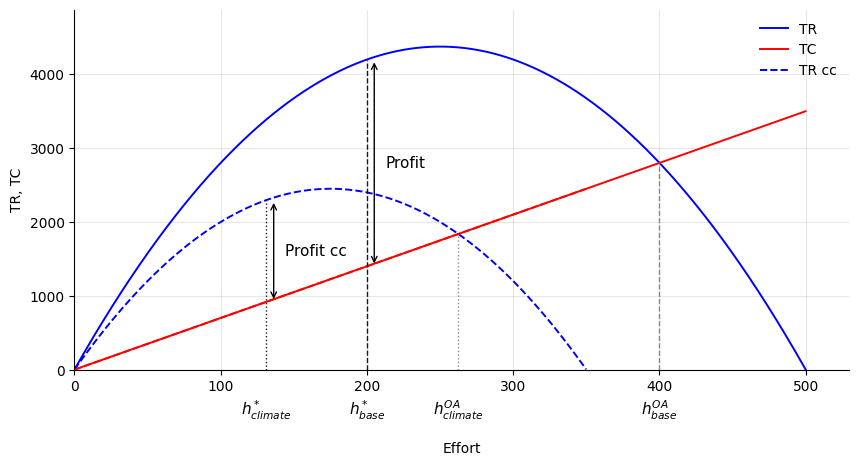

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from scipy.optimize import fmin

# ----------------------------
# Common parameters
# ----------------------------
theta = 0.001
p = 10
c = 7
lw = 1.4

# ----------------------------
# Scenarios
# ----------------------------
# Baseline
gamma_base = 0.5
Kmax_base = 3500

# Climate change scenario
# Example: lower reproduction and lower carrying capacity
gamma_cc = 0.35
Kmax_cc = 2800

def solve_fishery(gamma, Kmax, theta, p, c):
    # Stocks
    x = np.arange(1, Kmax + 1).reshape((Kmax, 1))

    # Biological growth
    dxdt = gamma * x * (1 - x / Kmax)

    # Sustainable effort
    effort_ss = (gamma * x * (1 - x / Kmax)) / (theta * x)

    # Revenue, cost, profit
    TR_ss = dxdt * p
    TC = effort_ss * c
    profits = TR_ss - TC

    # Open access equilibrium
    soa = c / (p * theta)
    eoa = gamma * soa * (1 - (soa / Kmax)) / (theta * soa)
    revs_oa = p * theta * soa * eoa
    cost_oa = c * eoa
    profits_oa = revs_oa - cost_oa

    # Profit-maximising equilibrium
    negative_profits = lambda xval: -1 * (
        (p * theta * xval - c) * (gamma * xval * (1 - (xval / Kmax))) / (theta * xval)
    )

    x_initial_guess = min(3000, Kmax - 1)
    x_star = fmin(negative_profits, x_initial_guess, disp=False)

    h_star = gamma * x_star * (1 - (x_star / Kmax)) / (theta * x_star)
    revs_star = p * theta * x_star * h_star
    cost_star = c * h_star
    profits_star = revs_star - cost_star

    # Flatten for plotting
    effort_ss = effort_ss.flatten()
    TR_ss = TR_ss.flatten()
    TC = TC.flatten()
    profits = profits.flatten()

    # Sort by effort so lines plot properly
    order = np.argsort(effort_ss)
    effort_ss = effort_ss[order]
    TR_ss = TR_ss[order]
    TC = TC[order]
    profits = profits[order]

    return {
        "gamma": gamma,
        "Kmax": Kmax,
        "x": x,
        "dxdt": dxdt,
        "effort_ss": effort_ss,
        "TR_ss": TR_ss,
        "TC": TC,
        "profits": profits,
        "soa": soa,
        "eoa": eoa,
        "revs_oa": revs_oa,
        "cost_oa": cost_oa,
        "profits_oa": profits_oa,
        "x_star": x_star[0],
        "h_star": h_star[0],
        "revs_star": revs_star[0],
        "cost_star": cost_star[0],
        "profits_star": profits_star[0]
    }

# Solve both scenarios
base = solve_fishery(gamma_base, Kmax_base, theta, p, c)
cc = solve_fishery(gamma_cc, Kmax_cc, theta, p, c)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Main lines
line_tr_base, = ax.plot(base["effort_ss"], base["TR_ss"], c="b", lw=lw, label="TR")
line_tc_base, = ax.plot(base["effort_ss"], base["TC"], c="r", lw=lw, label="TC")
line_tr_cc, = ax.plot(cc["effort_ss"], cc["TR_ss"], c="b", lw=lw, ls="--", label="TR cc")
ax.plot(cc["effort_ss"], cc["TC"], c="r", lw=lw, ls="--")

# Baseline equilibrium markers
ax.plot((base["h_star"], base["h_star"]), (0, base["revs_star"]), 'k--', alpha=0.9, lw=1.0)
ax.plot((base["eoa"], base["eoa"]), (0, c * base["eoa"]), 'grey', ls='--', alpha=0.9, lw=1.0)

ax.annotate(
    '',
    xy=(base["h_star"] + 5, base["revs_star"]),
    xytext=(base["h_star"] + 5, base["cost_star"]),
    arrowprops={'arrowstyle': '<->', 'lw': 1.0}
)
ax.annotate(
    'Profit',
    xy=(base["h_star"] + 5, (base["revs_star"] + base["cost_star"]) / 2),
    xytext=(8, 0),
    textcoords='offset points',
    fontsize=11,
    va='center'
)

# Climate equilibrium markers
ax.plot((cc["h_star"], cc["h_star"]), (0, cc["revs_star"]), 'k:', alpha=0.9, lw=1.0)
ax.plot((cc["eoa"], cc["eoa"]), (0, c * cc["eoa"]), color='grey', ls=':', alpha=0.9, lw=1.0)

ax.annotate(
    '',
    xy=(cc["h_star"] + 5, cc["revs_star"]),
    xytext=(cc["h_star"] + 5, cc["cost_star"]),
    arrowprops={'arrowstyle': '<->', 'lw': 1.0}
)
ax.annotate(
    'Profit cc',
    xy=(cc["h_star"] + 5, (cc["revs_star"] + cc["cost_star"]) / 2),
    xytext=(8, 0),
    textcoords='offset points',
    fontsize=11,
    va='center'
)

# Labels aligned on the same level just below the x-axis
xaxis_transform = ax.get_xaxis_transform()
label_y = -0.08

ax.text(
    base["h_star"], label_y, r'$h^*_{base}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    base["eoa"], label_y, r'$h^{OA}_{base}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    cc["h_star"], label_y, r'$h^*_{climate}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.text(
    cc["eoa"], label_y, r'$h^{OA}_{climate}$',
    transform=xaxis_transform,
    ha='center', va='top',
    fontsize=11, clip_on=False
)

ax.set_xlabel("Effort", labelpad=35)
ax.set_ylabel("TR, TC")
ax.set_xlim(0, max(base["effort_ss"].max(), cc["effort_ss"].max()) + 30)
ax.set_ylim(0, max(base["TR_ss"].max(), cc["TR_ss"].max()) + 500)
ax.grid(True, alpha=0.3)

# Custom legend
ax.legend(handles=[line_tr_base, line_tc_base, line_tr_cc], frameon=False)

sbn.despine()
plt.subplots_adjust(bottom=0.28)
plt.show()